# Capstone 24.1 — Notebook 2: Exploratory Data Analysis

**Author:** Sravanthi Gandu

Using the cleaned dataset from Notebook 1, we explore the distributions of the categorical
and continuous variables, how resolution duration varies across business dimensions, and
the weekly/monthly arrival pattern of tickets that motivates the volume-forecasting half of
the project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

# Render Plotly figures as static images so they display on GitHub
pio.renderers.default = "png"
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/cpt_clean.csv")
for c in ["create_date", "implementation_date"]:
    df[c] = pd.to_datetime(df[c], format="ISO8601", errors="coerce")
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded 47,684 rows x 33 columns


## 1. Categorical variables — where do tickets come from?

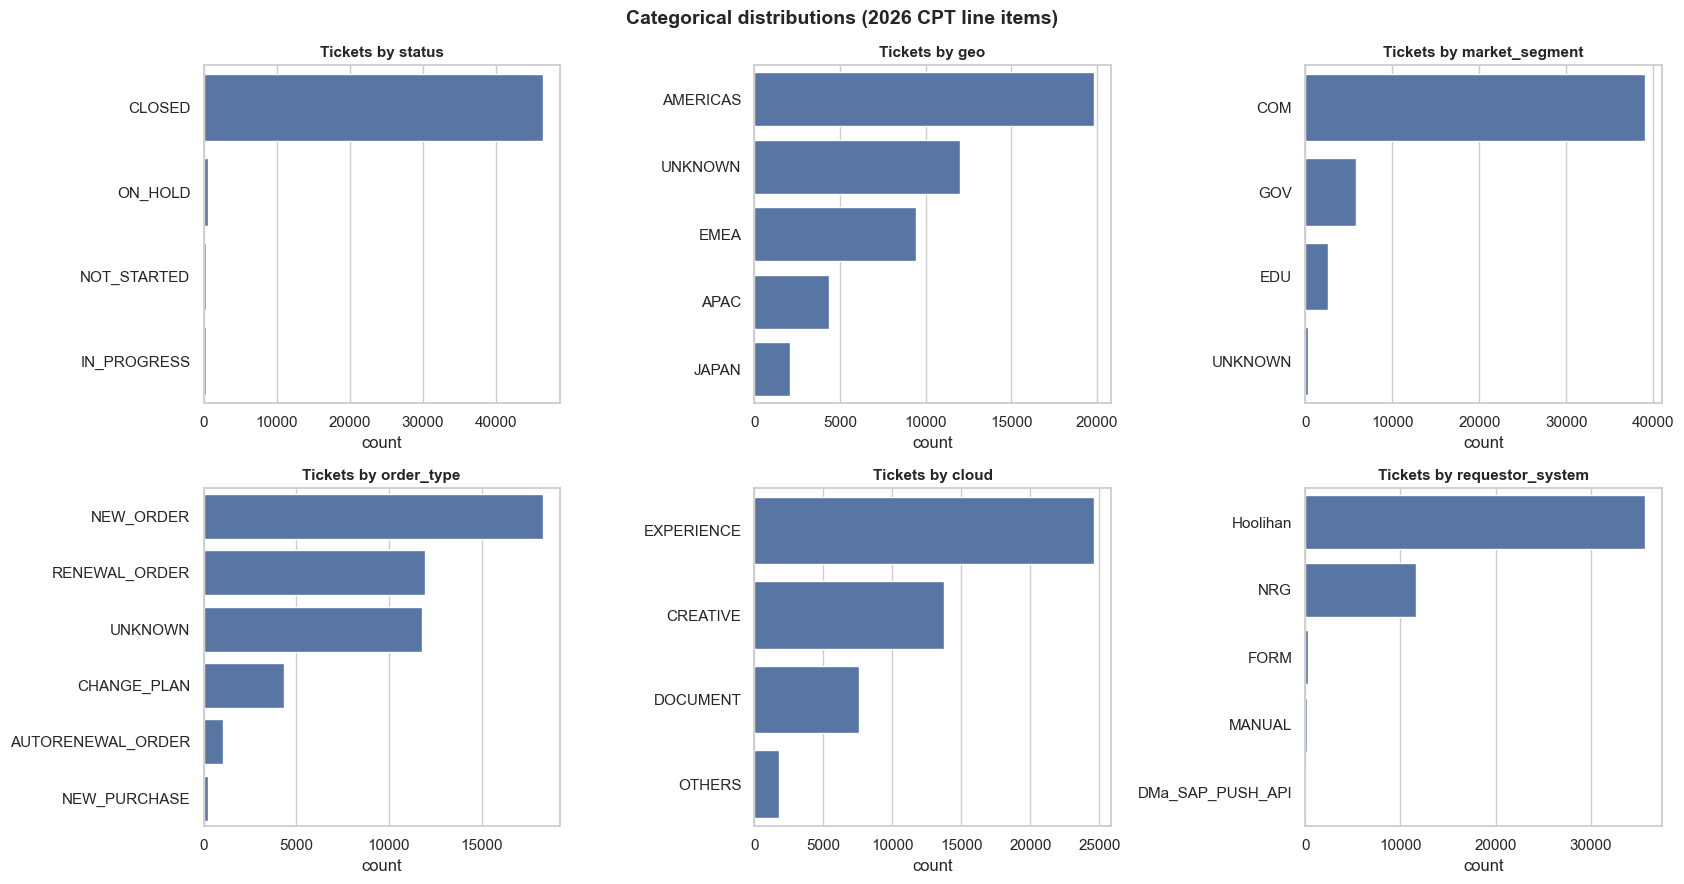

In [2]:
# Counts across the main business dimensions in a single figure
cat_plots = ["status", "geo", "market_segment", "order_type", "cloud", "requestor_system"]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for ax, col in zip(axes.ravel(), cat_plots):
    order = df[col].value_counts().head(8).index
    sns.countplot(data=df, y=col, order=order, color="#4C72B0", ax=ax)
    ax.set_title(f"Tickets by {col}", fontsize=11, weight="bold")
    ax.set_xlabel("count")
    ax.set_ylabel("")

plt.suptitle("Categorical distributions (2026 CPT line items)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

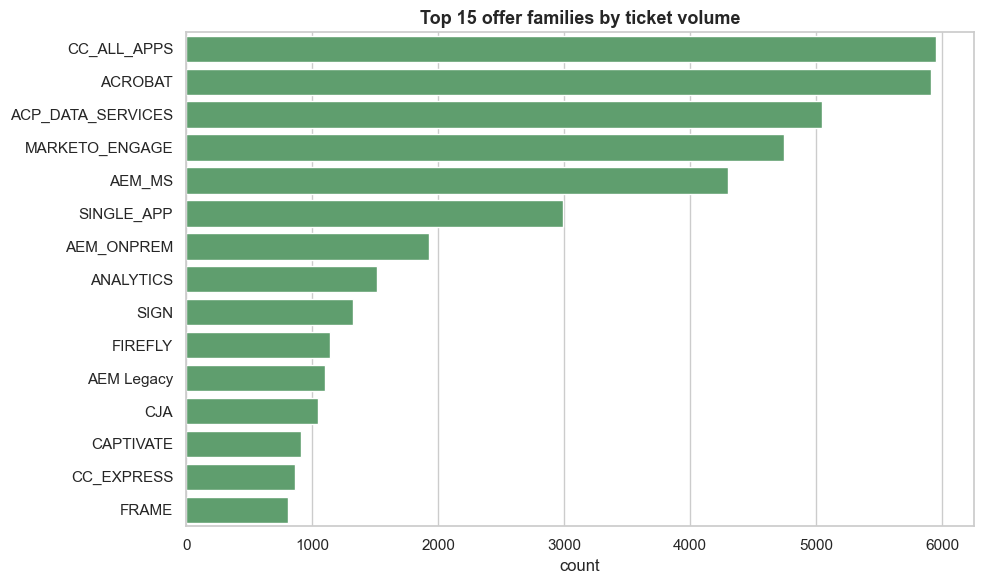

In [3]:
# Offer family is high-cardinality, so we show the top 15 separately
top_offers = df["offer_family"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_offers.values, y=top_offers.index, color="#55A868", ax=ax)
ax.set_title("Top 15 offer families by ticket volume", fontsize=13, weight="bold")
ax.set_xlabel("count")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 2. Continuous target — resolution duration

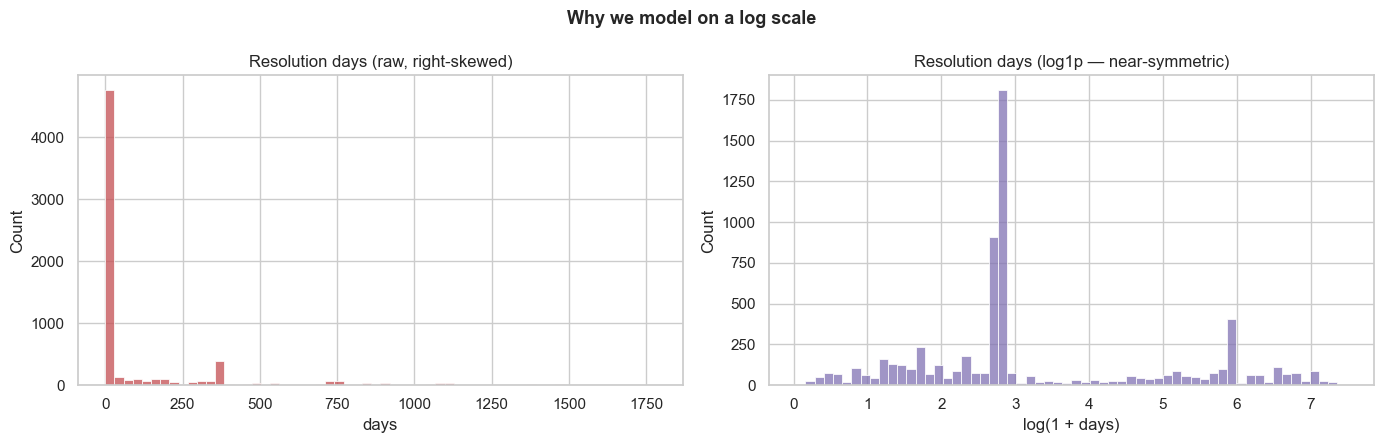

In [4]:
resolved = df[df["resolution_days"].notna() & (df["resolution_days"] > 0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(resolved["resolution_days"], bins=60, color="#C44E52", ax=axes[0])
axes[0].set_title("Resolution days (raw, right-skewed)")
axes[0].set_xlabel("days")
sns.histplot(np.log1p(resolved["resolution_days"]), bins=60, color="#8172B3", ax=axes[1])
axes[1].set_title("Resolution days (log1p — near-symmetric)")
axes[1].set_xlabel("log(1 + days)")
plt.suptitle("Why we model on a log scale", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

## 3. What drives longer resolution times?

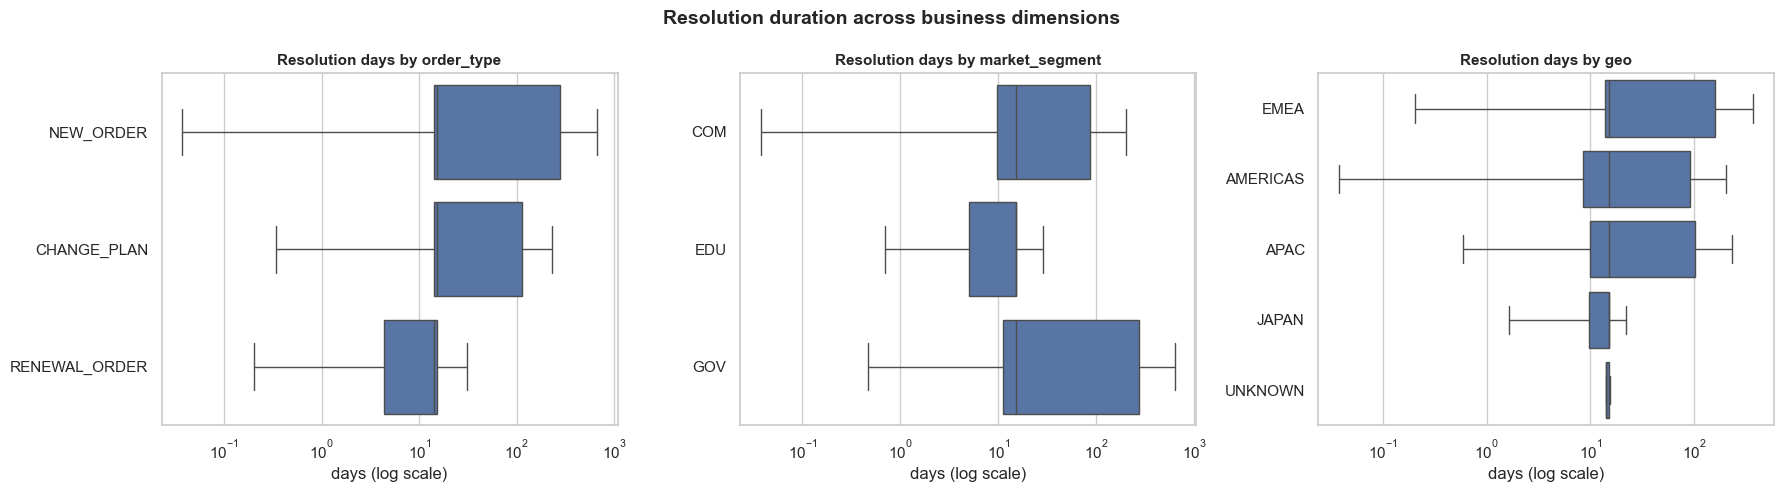

In [5]:
# Resolution duration by key categories (log scale to tame the skew)
drivers = ["order_type", "market_segment", "geo"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, drivers):
    order = resolved.groupby(col)["resolution_days"].median().sort_values(ascending=False).head(8).index
    sns.boxplot(data=resolved, x="resolution_days", y=col, order=order,
                showfliers=False, color="#4C72B0", ax=ax)
    ax.set_xscale("log")
    ax.set_title(f"Resolution days by {col}", fontsize=11, weight="bold")
    ax.set_xlabel("days (log scale)")
    ax.set_ylabel("")

plt.suptitle("Resolution duration across business dimensions", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

## 4. Correlation among numeric features

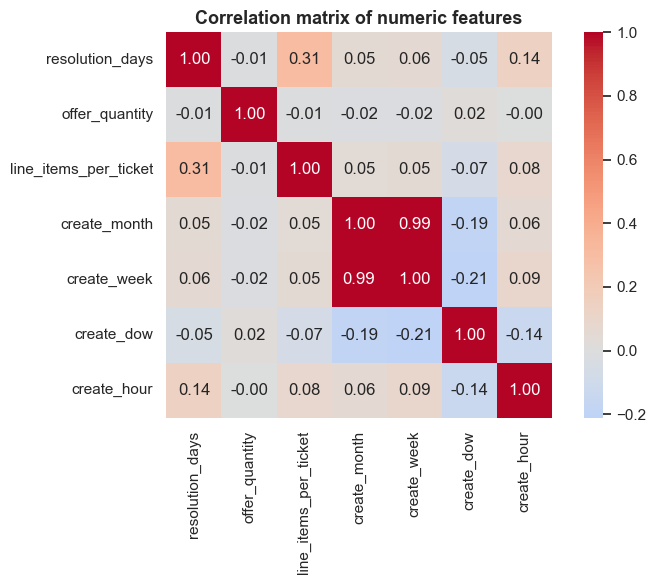

In [6]:
num_cols = ["resolution_days", "offer_quantity", "line_items_per_ticket",
            "create_month", "create_week", "create_dow", "create_hour"]
corr = resolved[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlation matrix of numeric features", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()

## 5. Ticket arrival pattern — the volume-forecasting signal

Aggregating ticket **creation** by ISO week reveals the arrival trend and spikes that the
forecasting half of the capstone aims to anticipate.

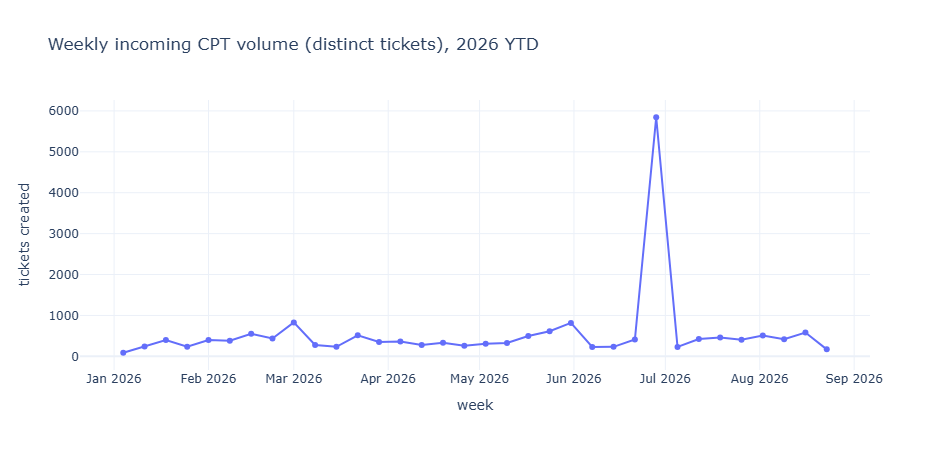

In [7]:
# Weekly ticket volume (distinct tickets, not line items)
weekly = (df.drop_duplicates("ticket_id")
            .set_index("create_date")
            .resample("W")["ticket_id"].nunique()
            .reset_index(name="tickets"))

fig = px.line(weekly, x="create_date", y="tickets", markers=True,
              title="Weekly incoming CPT volume (distinct tickets), 2026 YTD")
fig.update_layout(xaxis_title="week", yaxis_title="tickets created",
                  template="plotly_white", width=950, height=450)
fig.show()

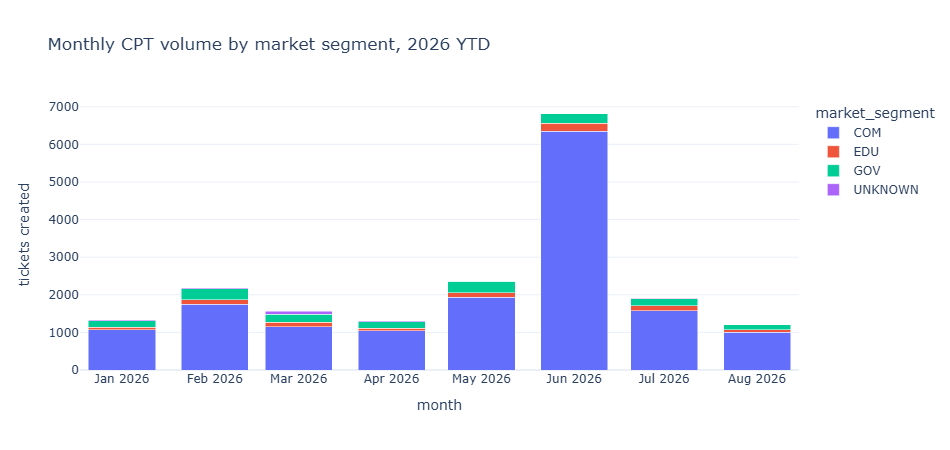

In [8]:
# Monthly volume split by market segment — a stacked view of the mix
monthly = (df.drop_duplicates("ticket_id")
             .assign(month=lambda d: d["create_date"].dt.to_period("M").astype(str))
             .groupby(["month", "market_segment"])["ticket_id"].nunique()
             .reset_index(name="tickets"))

fig = px.bar(monthly, x="month", y="tickets", color="market_segment",
             title="Monthly CPT volume by market segment, 2026 YTD",
             barmode="stack")
fig.update_layout(xaxis_title="month", yaxis_title="tickets created",
                  template="plotly_white", width=950, height=450)
fig.show()

## Key EDA takeaways

* **Volume is uneven week to week**, with clear spikes — supporting the need for a forward
  volume forecast rather than flat staffing.
* **COM (commercial)** dominates volume, but **GOV/EDU** and certain **offer families**
  and **order types** carry visibly longer resolution tails.
* **Resolution duration is heavily right-skewed**, so downstream regression is done on
  `log1p(resolution_days)`.
* Numeric features are only weakly correlated with each other, so the categorical business
  dimensions carry most of the predictive signal.

**Next:** [03 — Modeling: Resolution-Time Regression](03_modeling_regression.ipynb)